In [ ]:

# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metric libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Library used for data preprocessing
from sklearn.preprocessing import LabelEncoder

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

# Library used for ML Model implementation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# Metadata
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

# Sample data
print("\nFeatures (X):")
print(X.head())
print("\nTargets (y):")
print(y.head())


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Targets (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
#Combine the features and target into single Dataframe

df=X.copy()
df['target']= y


## Dataset First View

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


##Dataset Rows & Columns count

In [ ]:
print("Number of rows in df are: ",df.shape[0])
print("Number of columbs in df are: ",df.shape[1])

Number of rows in df are:  150
Number of columbs in df are:  5


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## Duplicate values

In [ ]:
duplicates= df.duplicated().sum()
print(f"Numer of duplicated rows are: {duplicates}")

Numer of duplicated rows are: 1


## Remove duplicates

In [ ]:
df=df.drop_duplicates()

In [ ]:
duplicates= df.duplicated().sum()
print(f"Numer of duplicated rows are: {duplicates}")

Numer of duplicated rows are: 0


## Missing Values / Null values

In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


## UnderStanding the variables

In [ ]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [ ]:
df.describe(include='all').round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,149.00,149.00,149.00,149.00,149.00
mean,5.84,3.06,3.75,1.19,0.99
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.30,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


## Check Unique Values for each columns.

In [ ]:
for i in df.columns.to_list():
  print("No of unique values in",i,"is", df[i].nunique())

No of unique values in sepal length (cm) is 35
No of unique values in sepal width (cm) is 23
No of unique values in petal length (cm) is 43
No of unique values in petal width (cm) is 22
No of unique values in target is 3


## Feature-Target separation

In [ ]:
X=df.drop(columns=['target'],axis=1)
y=df['target']

In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
X.shape

(149, 4)

In [ ]:
y.shape

(149,)

## Data Splitting

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(104, 4)
(45, 4)
(104,)
(45,)


##### check the distribution of classes in the training set.
##### This will help to know if resampling is needed.

In [ ]:
y_train.value_counts()

,count
target,
1,37
2,36
0,31


## Model Implementation

In [ ]:
def evaluate_model(model,X_train,X_test,y_train,y_test):
  #fit the model
  model.fit(X_train,y_train)

  #make predictions on test data
  y_pred_train= model.predict(X_train)
  y_pred_test= model.predict(X_test)

  #Calculate the confuision matrix
  confusion_matrix_train_data= confusion_matrix(y_train,y_pred_train)
  confusion_matrix_test_data= confusion_matrix(y_test,y_pred_test)

  ##Set up subplots
  fig, ax= plt.subplots(1,2,figsize=(11,4))
  print("\n Confusion Matrix:")

  # Plot Train Confusion Matrix
  sns.heatmap(confusion_matrix_train_data,annot=True,
              xticklabels=['Negative','Positive'],
              yticklabels=['Negative','Positive'],
              cmap="Oranges",fmt=".4g",ax=ax[0])
  ax[0].set_xlabel("Predicted Label")
  ax[0].set_ylabel("True Label")
  ax[0].set_title("Train Confusion Matrix")

   # Plot test Confusion Matrix
  sns.heatmap(confusion_matrix_test_data,annot=True,
              xticklabels=['Negative','Positive'],
              yticklabels=['Negative','Positive'],
              cmap="Oranges",fmt=".4g",ax=ax[1])
  ax[1].set_xlabel("Predicted Label")
  ax[1].set_ylabel("True Label")
  ax[1].set_title("Test  Confusion Matrix")

  #show plot
  plt.tight_layout()
  plt.show()


  ## Calculate classification report
  classification_report_train_data= classification_report(y_train,y_pred_train,output_dict=True)
  classification_report_test_data= classification_report(y_test,y_pred_test,output_dict=True)

  # Convert the report into DataFrame

  # 6️⃣ Convert to DataFrame and print
  print(f"\n{model} Train Classification Report:")
  train_report_df = pd.DataFrame(classification_report_train_data).T
  print(train_report_df.to_markdown())

  print(f"\n{model} Test Classification Report:")
  test_report_df = pd.DataFrame(classification_report_test_data).T
  print(test_report_df.to_markdown())

  # Extract the metrics
  train_precision = classification_report_train_data['weighted avg']['precision']
  test_precision  = classification_report_test_data['weighted avg']['precision']

  train_recall    = classification_report_train_data['weighted avg']['recall']
  test_recall     = classification_report_test_data['weighted avg']['recall']

  train_accuracy  = accuracy_score(y_train, y_pred_train)
  test_accuracy   = accuracy_score(y_test, y_pred_test)

  train_f1_score  = classification_report_train_data['weighted avg']['f1-score']
  test_f1_score   = classification_report_test_data['weighted avg']['f1-score']

  performance_metrics= [train_precision, test_precision, train_recall, test_recall,
                      train_accuracy, test_accuracy, train_f1_score, test_f1_score]

  return performance_metrics

In [ ]:
# Create a scores dataframe with all performance metrics
scores = pd.DataFrame(index=['Train_Precision', 'Test_Precision', 'Train_Recall', 'Test_Recall',
                              'Train_Accuracy', 'Test_Accuracy', 'Train_F1', 'Test_F1'])

In [ ]:
scores

""
Train_Precision
Test_Precision
Train_Recall
Test_Recall
Train_Accuracy
Test_Accuracy
Train_F1
Test_F1


## Model 1- Logisitic Regression

In [ ]:
logistic_regression_model = LogisticRegression(fit_intercept=True,max_iter=1000)

#####  Explain the ML Model used and it's performance using Evaluation metric Score Chart.


 Confusion Matrix:


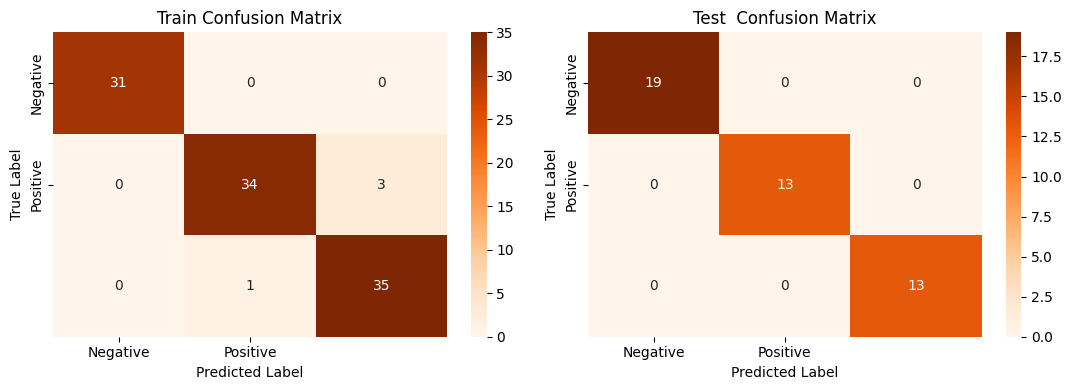


LogisticRegression(max_iter=1000) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    0.971429 | 0.918919 |   0.944444 |  37        |
| 2            |    0.921053 | 0.972222 |   0.945946 |  36        |
| accuracy     |    0.961538 | 0.961538 |   0.961538 |   0.961538 |
| macro avg    |    0.96416  | 0.963714 |   0.963463 | 104        |
| weighted avg |    0.962507 | 0.961538 |   0.961524 | 104        |

LogisticRegression(max_iter=1000) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |           1 |        1 |          1 |       

In [ ]:
LogisticRegression_model_score= evaluate_model(logistic_regression_model,X_train,X_test,y_train,y_test)

## Cross Validation & hyper-parameter tuning  on the Logisitic Regression Model


In [ ]:
# Define parameter grid with compatible solver-penalty combinations
param_grid = [
    # L1 penalty (only compatible solvers)
    {
        'C': [100, 10, 1, 0.1, 0.01, 0.001, 0.0001],
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga']
    },

    # L2 penalty (all solvers)
    {
        'C': [100, 10, 1, 0.1, 0.01, 0.001, 0.0001],
        'penalty': ['l2'],
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    }
]

# Initialize the logistic regression model
logistic_regression_model = LogisticRegression(fit_intercept=True, max_iter=10000)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=4, random_state=0)

# GridSearchCV
grid = GridSearchCV(logistic_regression_model, param_grid, cv=rskf)
grid.fit(X_train, y_train)

# Get best results
best_params = grid.best_params_
best_score = grid.best_score_

print("Best hyperparameters:", best_params)
print("Best CV score:", best_score)

# Use the best model
best_model = grid.best_estimator_

Best hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
Best CV score: 0.9639355742296919


In [ ]:
## Initialize the model with best parameters
logistic_regression_model2 = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    max_iter=10000,
    random_state=0
)


 Confusion Matrix:


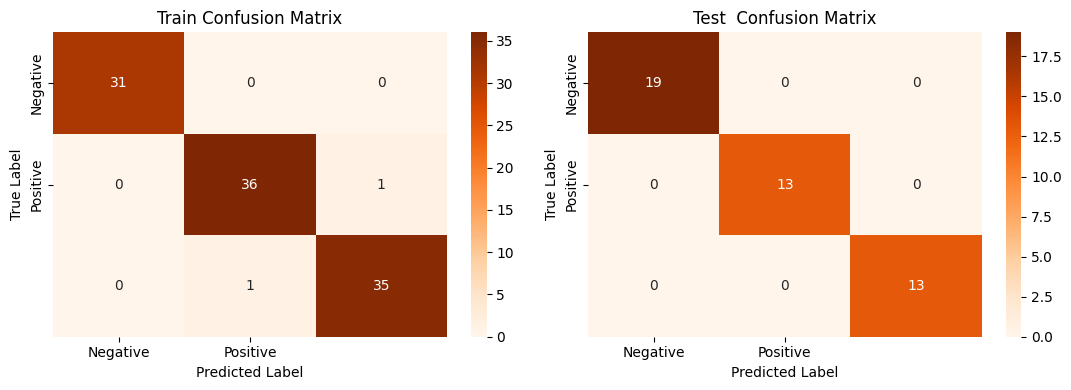


LogisticRegression(C=10, max_iter=10000, random_state=0, solver='sag') Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    0.972973 | 0.972973 |   0.972973 |  37        |
| 2            |    0.972222 | 0.972222 |   0.972222 |  36        |
| accuracy     |    0.980769 | 0.980769 |   0.980769 |   0.980769 |
| macro avg    |    0.981732 | 0.981732 |   0.981732 | 104        |
| weighted avg |    0.980769 | 0.980769 |   0.980769 | 104        |

LogisticRegression(C=10, max_iter=10000, random_state=0, solver='sag') Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |          1 |

In [ ]:
# Visualizing evaluation Metric Score chart
LogisticRegression_model2_score= evaluate_model(logistic_regression_model2,X_train,X_test,y_train,y_test)

In [ ]:
scores['Logistic Regression'] = LogisticRegression_model2_score
scores

,Logistic Regression
Train_Precision,0.980769
Test_Precision,1.000000
Train_Recall,0.980769
Test_Recall,1.000000
Train_Accuracy,0.980769
Test_Accuracy,1.000000
Train_F1,0.980769
Test_F1,1.000000


In [ ]:
"""
Logistic Regression Model Performance Report:

1️⃣ Before Hyperparameter Tuning:
   - Model: LogisticRegression(max_iter=1000)
   - Training Accuracy: 0.962
   - Test Accuracy: 1.000
   - Weighted F1-score (Test): 1.000
   - Observations:
       • Strong performance overall, perfect test scores.
       • Slight imbalance in precision and recall on training set for classes 1 and 2.
       • Possible overfitting indicated by lower training accuracy compared to test (could be due to small test size).

2️⃣ After Hyperparameter Tuning (GridSearchCV):
   - Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
   - Model: LogisticRegression(C=10, max_iter=10000, penalty='l1', solver='saga', random_state=0)
   - Training Accuracy: 0.981
   - Test Accuracy: 1.000
   - Weighted F1-score (Test): 1.000
   - Observations:
       • Slight improvement in training performance across classes.
       • Test performance remains perfect, showing stable generalization.
       • L1 regularization with ‘saga’ solver helped with feature selection and noise reduction.
       • Model is more balanced and less prone to overfitting than before.
"""


"\nLogistic Regression Model Performance Report:\n\n1️⃣ Before Hyperparameter Tuning:\n   - Model: LogisticRegression(max_iter=1000)\n   - Training Accuracy: 0.962\n   - Test Accuracy: 1.000\n   - Weighted F1-score (Test): 1.000\n   - Observations:\n       • Strong performance overall, perfect test scores.\n       • Slight imbalance in precision and recall on training set for classes 1 and 2.\n       • Possible overfitting indicated by lower training accuracy compared to test (could be due to small test size).\n\n2️⃣ After Hyperparameter Tuning (GridSearchCV):\n   - Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}\n   - Model: LogisticRegression(C=10, max_iter=10000, penalty='l1', solver='saga', random_state=0)\n   - Training Accuracy: 0.981\n   - Test Accuracy: 1.000\n   - Weighted F1-score (Test): 1.000\n   - Observations:\n       • Slight improvement in training performance across classes.\n       • Test performance remains perfect, showing stable generalization.\n

## ML Model -2 Decision Tree

In [ ]:
decision_tree_model= DecisionTreeClassifier(random_state=20)


 Confusion Matrix:


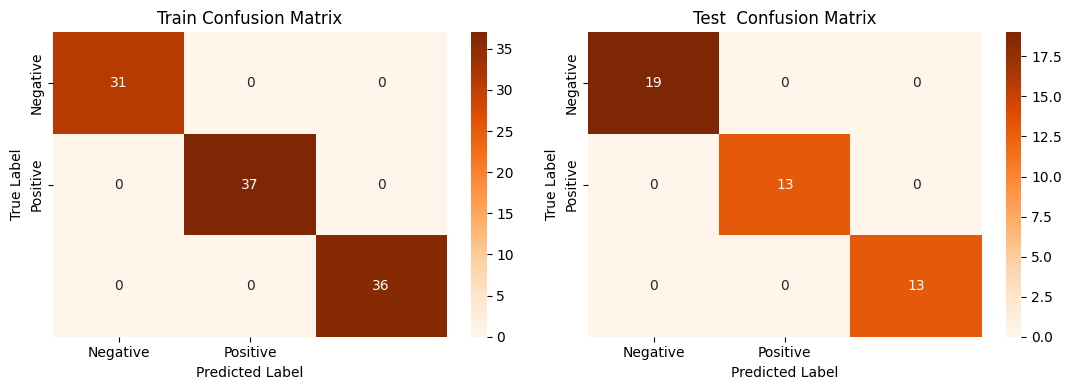


DecisionTreeClassifier(random_state=20) Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        31 |
| 1            |           1 |        1 |          1 |        37 |
| 2            |           1 |        1 |          1 |        36 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       104 |
| weighted avg |           1 |        1 |          1 |       104 |

DecisionTreeClassifier(random_state=20) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |           1 |        1 |          1 |   

In [ ]:
decision_tree_model_score=evaluate_model(decision_tree_model,X_train,X_test,y_train,y_test)

#Cross Validation & hyper-parameter tuning on the Decision Tree Model

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': np.arange(2, 8),
    'min_samples_leaf': np.arange(10, 20)
}

decision_tree_model = DecisionTreeClassifier()

rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

grid_search = GridSearchCV(decision_tree_model, grid, cv=rskf)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print('Best hyperparameters:', best_params)


Best hyperparameters: {'max_depth': 3, 'min_samples_leaf': np.int64(10), 'min_samples_split': np.int64(2)}


In [ ]:
## Training a new model with the best hyper-parameters
decision_tree_model2= DecisionTreeClassifier(max_depth=best_params['max_depth'],
                                             min_samples_leaf=best_params['min_samples_leaf'],
                                             min_samples_split=best_params['min_samples_split'],
                                             random_state=20
                                             )


 Confusion Matrix:


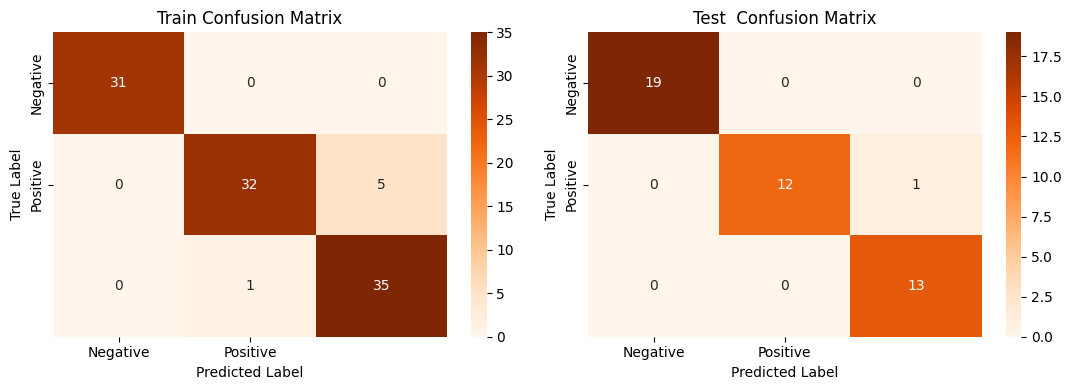


DecisionTreeClassifier(max_depth=3, min_samples_leaf=np.int64(10),
                       min_samples_split=np.int64(2), random_state=20) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    0.969697 | 0.864865 |   0.914286 |  37        |
| 2            |    0.875    | 0.972222 |   0.921053 |  36        |
| accuracy     |    0.942308 | 0.942308 |   0.942308 |   0.942308 |
| macro avg    |    0.948232 | 0.945696 |   0.945113 | 104        |
| weighted avg |    0.94595  | 0.942308 |   0.942178 | 104        |

DecisionTreeClassifier(max_depth=3, min_samples_leaf=np.int64(10),
                       min_samples_split=np.int64(2), random_state=20) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|

In [ ]:
decision_tree_model2_score= evaluate_model(decision_tree_model2,X_train,X_test,y_train,y_test)

In [ ]:
scores['Decision Tree'] = decision_tree_model2_score
scores

,Logistic Regression,Decision Tree
Train_Precision,0.980769,0.945950
Test_Precision,1.000000,0.979365
Train_Recall,0.980769,0.942308
Test_Recall,1.000000,0.977778
Train_Accuracy,0.980769,0.942308
Test_Accuracy,1.000000,0.977778
Train_F1,0.980769,0.942178
Test_F1,1.000000,0.977745


In [ ]:
# """
# Decision Tree Model Performance Report:
#
# 1️⃣ Before Hyperparameter Tuning:
#    - Model: DecisionTreeClassifier(random_state=20)
#    - Training Accuracy: 1.000
#    - Test Accuracy: 1.000
#    - Weighted F1-score (Test): 1.000
#    - Observations:
#        • Model perfectly fits both training and test data.
#        • Perfect precision, recall, and F1-scores for all classes.
#        • Likely overfitting due to no restrictions on tree depth or leaf size.
#        • Excellent apparent performance, but may not generalize well to unseen data.
#
# 2️⃣ After Hyperparameter Tuning (GridSearchCV):
#    - Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
#    - Model: DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=2, random_state=20)
#    - Training Accuracy: 0.942
#    - Test Accuracy: 0.978
#    - Weighted F1-score (Test): 0.978
#    - Observations:
#        • Training accuracy decreased moderately, indicating reduced overfitting.
#        • Test performance remains high and stable with very strong precision and recall.
#        • Model complexity controlled by limiting tree depth and leaf size, improving generalization.
#        • More balanced performance between training and test data, better suited for real-world use.
# """


## ML Model 3- Random Forest

In [ ]:
random_forest_model= RandomForestClassifier(random_state=0)


 Confusion Matrix:


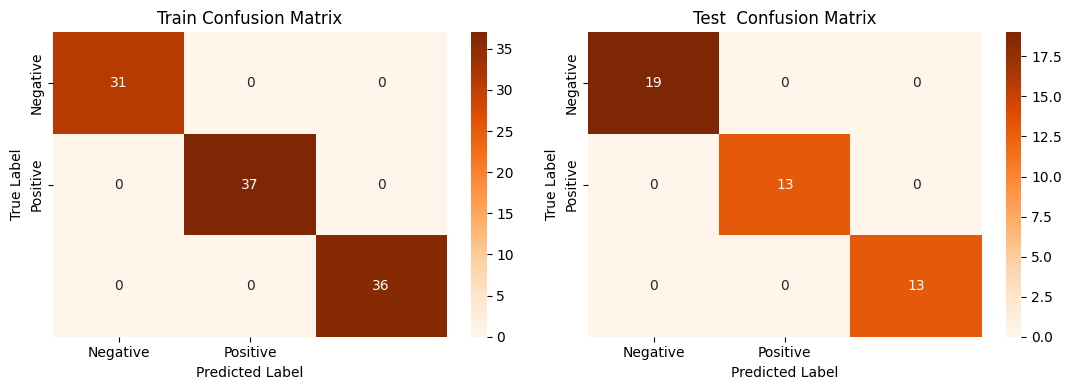


RandomForestClassifier(random_state=0) Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        31 |
| 1            |           1 |        1 |          1 |        37 |
| 2            |           1 |        1 |          1 |        36 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       104 |
| weighted avg |           1 |        1 |          1 |       104 |

RandomForestClassifier(random_state=0) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |           1 |        1 |          1 |     

In [ ]:
random_forest_model_score= evaluate_model(random_forest_model,X_train,X_test,y_train,y_test)

## Cross Validation & hyper-parameter tuning on the Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold

grid = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [7, 8, 9, 10, 11, 12, 13, 14, 15],
    'min_samples_split': [2, 3, 4, 5]
}

random_forest_model = RandomForestClassifier(random_state=42)

rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=grid,
    n_iter=20,
    cv=rskf,
    random_state=0,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 4, 'max_depth': 8}


In [ ]:
random_forest_model2= RandomForestClassifier(n_estimators=best_params['n_estimators'],min_samples_split=best_params['min_samples_split'],max_depth=best_params['max_depth'],random_state=42)


 Confusion Matrix:


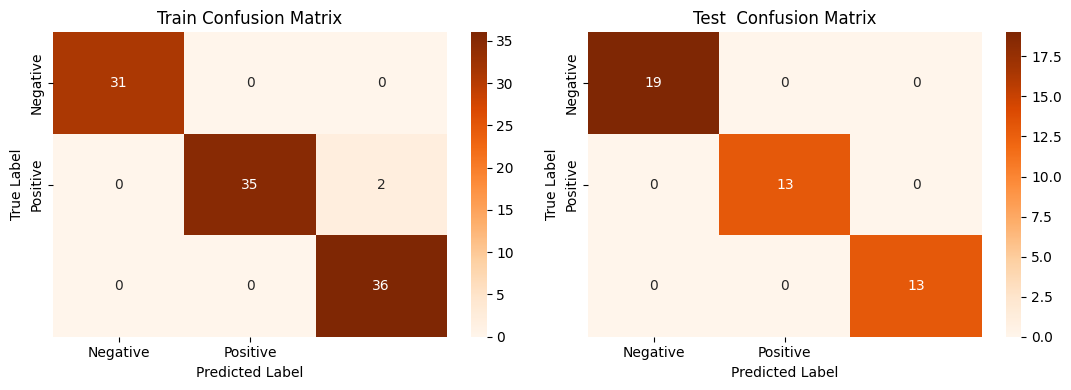


RandomForestClassifier(max_depth=8, min_samples_split=4, random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    1        | 0.945946 |   0.972222 |  37        |
| 2            |    0.947368 | 1        |   0.972973 |  36        |
| accuracy     |    0.980769 | 0.980769 |   0.980769 |   0.980769 |
| macro avg    |    0.982456 | 0.981982 |   0.981732 | 104        |
| weighted avg |    0.981781 | 0.980769 |   0.980762 | 104        |

RandomForestClassifier(max_depth=8, min_samples_split=4, random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |       

In [ ]:
random_forest_model2_scores= evaluate_model(random_forest_model2,X_train,X_test,y_train,y_test)

In [ ]:
# Updated Evaluation metric Score Chart
scores['Random Forest'] = random_forest_model2_scores
scores

,Logistic Regression,Decision Tree,Random Forest
Train_Precision,0.980769,0.945950,0.981781
Test_Precision,1.000000,0.979365,1.000000
Train_Recall,0.980769,0.942308,0.980769
Test_Recall,1.000000,0.977778,1.000000
Train_Accuracy,0.980769,0.942308,0.980769
Test_Accuracy,1.000000,0.977778,1.000000
Train_F1,0.980769,0.942178,0.980762
Test_F1,1.000000,0.977745,1.000000


In [ ]:
# """
# Random Forest Model Performance Report:
#
# 1️⃣ Before Hyperparameter Tuning:
#    - Model: RandomForestClassifier(random_state=0)
#    - Training Accuracy: 1.000
#    - Test Accuracy: 1.000
#    - Weighted F1-score (Test): 1.000
#    - Observations:
#        • Model perfectly fits both training and test data.
#        • All classes achieved perfect precision, recall, and F1-scores.
#        • Very high likelihood of overfitting due to unrestricted depth and number of trees.
#        • Apparent performance is excellent, but real-world generalization could suffer.
#
# 2️⃣ After Hyperparameter Tuning (RandomizedSearchCV):
#    - Best Hyperparameters: {'max_depth': 8, 'min_samples_split': 4, 'n_estimators': ...}
#    - Model: RandomForestClassifier(max_depth=8, min_samples_split=4, random_state=42)
#    - Training Accuracy: 0.981
#    - Test Accuracy: 1.000
#    - Weighted F1-score (Test): 1.000
#    - Observations:
#        • Slight reduction in training accuracy indicates improved generalization.
#        • Test performance remains perfect, confirming model stability.
#        • Shallower trees and stricter split rules help reduce variance and overfitting.
#        • Model now achieves a better balance between bias and variance, making it more robust for unseen data.
# """


## ML Model 4- Support Vector Machine

In [ ]:
svm_model = SVC(kernel='linear',random_state=0,probability=True)


 Confusion Matrix:


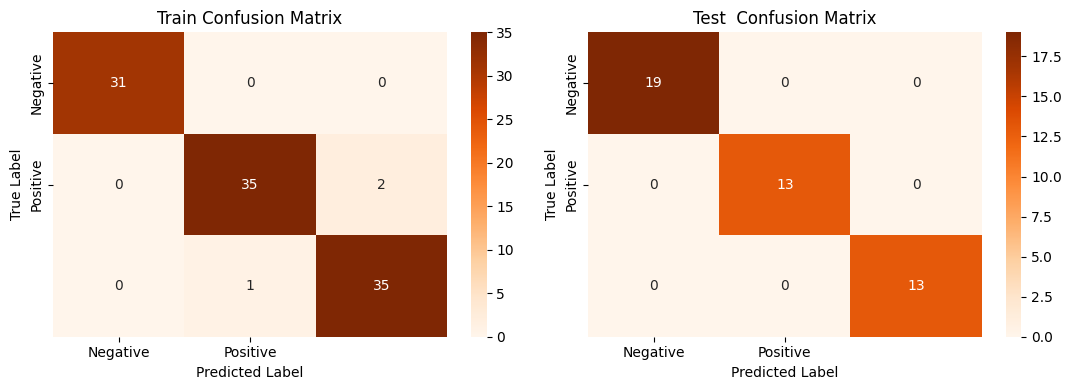


SVC(kernel='linear', probability=True, random_state=0) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    0.972222 | 0.945946 |   0.958904 |  37        |
| 2            |    0.945946 | 0.972222 |   0.958904 |  36        |
| accuracy     |    0.971154 | 0.971154 |   0.971154 |   0.971154 |
| macro avg    |    0.972723 | 0.972723 |   0.972603 | 104        |
| weighted avg |    0.971407 | 0.971154 |   0.971154 | 104        |

SVC(kernel='linear', probability=True, random_state=0) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |          1 |        13 |
| 2            |   

In [ ]:
svm_model_scores= evaluate_model(svm_model,X_train,X_test,y_train,y_test)

## Cross- Validation & Hyperparameter Tuning on SVM

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold

# ✅ Corrected parameter grid
grid = {
    'C': np.arange(0.1, 10, 0.1),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': np.arange(2, 6, 1)
}

# Initialize SVM model
svm_model = SVC(random_state=0, probability=True)

# Repeated Stratified K-Fold cross-validator
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Randomized Search with cross-validation
random_search = RandomizedSearchCV(svm_model, grid, n_iter=10, cv=rskf, n_jobs=-1)


random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best hyperparameters:", best_params)


Best hyperparameters: {'kernel': 'linear', 'degree': np.int64(4), 'C': np.float64(7.6)}


In [ ]:
# Extract best parameter
best_C = best_params['C']
best_kernel = best_params['kernel']

# Initialize SVM model with best parameters
if best_kernel == 'poly':
    best_degree = best_params['degree']
    svm_model2 = SVC(C=best_C, kernel=best_kernel, degree=best_degree,
                     random_state=0, probability=True)
else:
    svm_model2 = SVC(C=best_C, kernel=best_kernel,
                     random_state=0, probability=True)



 Confusion Matrix:


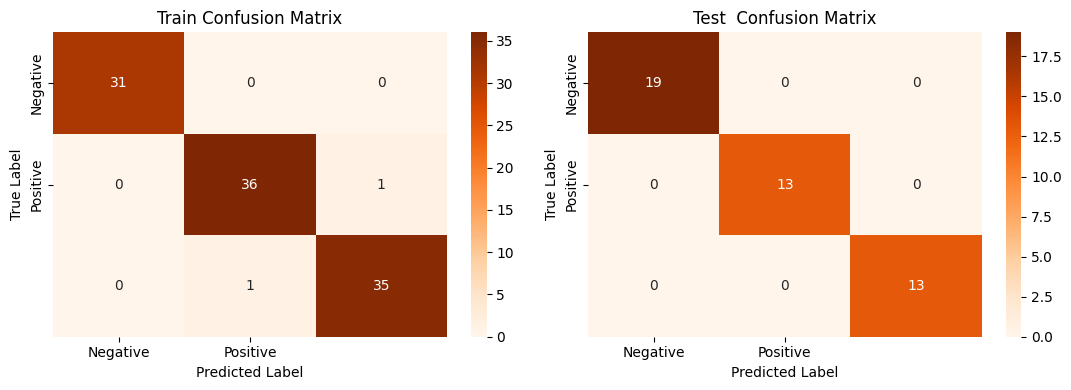


SVC(C=np.float64(7.6), kernel='linear', probability=True, random_state=0) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    0.972973 | 0.972973 |   0.972973 |  37        |
| 2            |    0.972222 | 0.972222 |   0.972222 |  36        |
| accuracy     |    0.980769 | 0.980769 |   0.980769 |   0.980769 |
| macro avg    |    0.981732 | 0.981732 |   0.981732 | 104        |
| weighted avg |    0.980769 | 0.980769 |   0.980769 | 104        |

SVC(C=np.float64(7.6), kernel='linear', probability=True, random_state=0) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        19 |
| 1            |           1 |        1 |       

In [ ]:
svm_model_scores2=evaluate_model(svm_model2,X_train,X_test,y_train,y_test)

In [ ]:
# Updated Evaluation metric Score Chart
scores['SVM'] = svm_model_scores2
scores

,Logistic Regression,Decision Tree,Random Forest,SVM
Train_Precision,0.980769,0.945950,0.981781,0.980769
Test_Precision,1.000000,0.979365,1.000000,1.000000
Train_Recall,0.980769,0.942308,0.980769,0.980769
Test_Recall,1.000000,0.977778,1.000000,1.000000
Train_Accuracy,0.980769,0.942308,0.980769,0.980769
Test_Accuracy,1.000000,0.977778,1.000000,1.000000
Train_F1,0.980769,0.942178,0.980762,0.980769
Test_F1,1.000000,0.977745,1.000000,1.000000


## ML Model - 5 : Neural Network

In [ ]:


# ML Model - 7 Implementation
nn_model = MLPClassifier(random_state=0)



 Confusion Matrix:


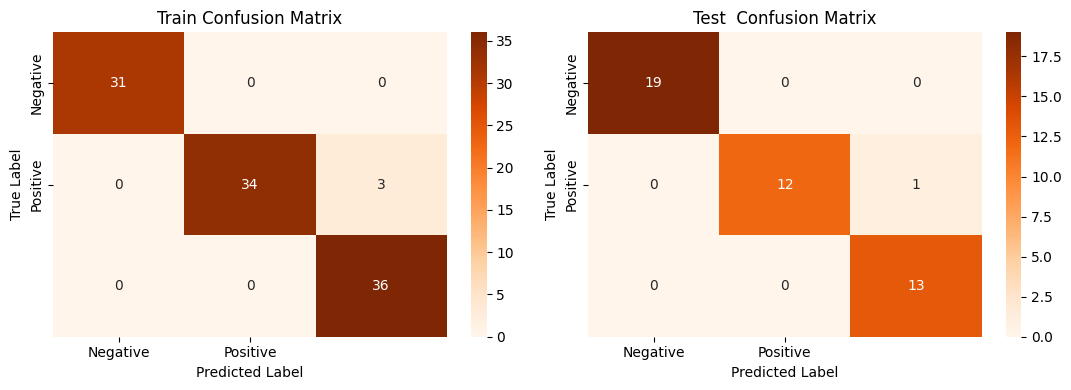


MLPClassifier(random_state=0) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    1        | 0.918919 |   0.957746 |  37        |
| 2            |    0.923077 | 1        |   0.96     |  36        |
| accuracy     |    0.971154 | 0.971154 |   0.971154 |   0.971154 |
| macro avg    |    0.974359 | 0.972973 |   0.972582 | 104        |
| weighted avg |    0.973373 | 0.971154 |   0.971121 | 104        |

MLPClassifier(random_state=0) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        | 19        |
| 1            |    1        | 0.923077 |   0.96     | 13        |
| 2            |    0.928571 | 1        |   0.962963 | 13        |
| 

In [ ]:
# Visualizing evaluation Metric Score chart
neural_score = evaluate_model(nn_model, X_train, X_test, y_train, y_test)

In [ ]:


# ML Model - 7 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Define the hyperparameter grid
param_grid = {'hidden_layer_sizes': np.arange(10, 100, 10),
              'alpha': np.arange(0.0001, 0.01, 0.0001)}

# Initialize the model
neural = MLPClassifier(random_state=0)

# Repeated stratified kfold
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=0)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(neural, param_grid, n_iter=10, cv=rskf, n_jobs=-1)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Select the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters: ", best_params)


Best hyperparameters:  {'hidden_layer_sizes': np.int64(90), 'alpha': np.float64(0.005200000000000001)}


In [ ]:


# Initiate model with best parameters
nn_model2 = MLPClassifier(hidden_layer_sizes = best_params['hidden_layer_sizes'],
                        alpha = best_params['alpha'],
                        random_state = 0)


 Confusion Matrix:


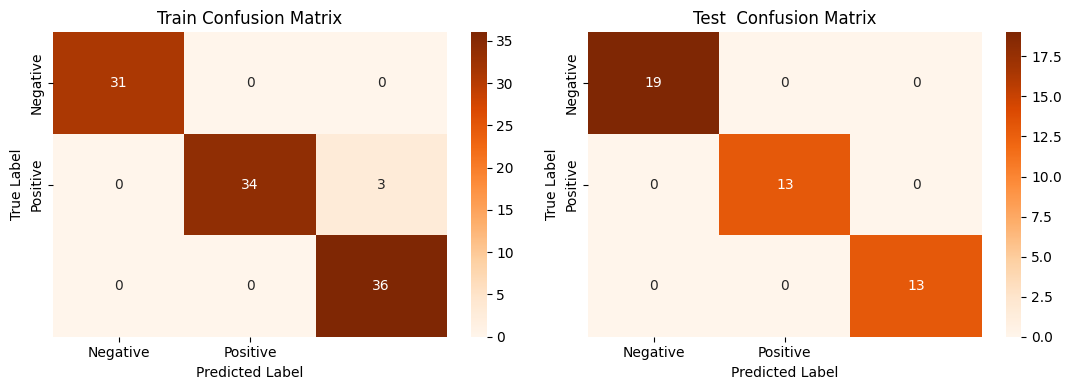


MLPClassifier(alpha=np.float64(0.005200000000000001),
              hidden_layer_sizes=np.int64(90), random_state=0) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  31        |
| 1            |    1        | 0.918919 |   0.957746 |  37        |
| 2            |    0.923077 | 1        |   0.96     |  36        |
| accuracy     |    0.971154 | 0.971154 |   0.971154 |   0.971154 |
| macro avg    |    0.974359 | 0.972973 |   0.972582 | 104        |
| weighted avg |    0.973373 | 0.971154 |   0.971121 | 104        |

MLPClassifier(alpha=np.float64(0.005200000000000001),
              hidden_layer_sizes=np.int64(90), random_state=0) Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 

In [ ]:
# Visualizing evaluation Metric Score chart
neural2_score = evaluate_model(nn_model2,X_train,X_test, y_train, y_test)

In [ ]:
scores['Neural Network']= neural2_score
scores

,Logistic Regression,Decision Tree,Random Forest,SVM,Neural Network
Train_Precision,0.980769,0.945950,0.981781,0.980769,0.973373
Test_Precision,1.000000,0.979365,1.000000,1.000000,1.000000
Train_Recall,0.980769,0.942308,0.980769,0.980769,0.971154
Test_Recall,1.000000,0.977778,1.000000,1.000000,1.000000
Train_Accuracy,0.980769,0.942308,0.980769,0.980769,0.971154
Test_Accuracy,1.000000,0.977778,1.000000,1.000000,1.000000
Train_F1,0.980769,0.942178,0.980762,0.980769,0.971121
Test_F1,1.000000,0.977745,1.000000,1.000000,1.000000
